# Figure 4(C) — Geometric-defect reduction after PDB-REDO

Issue rates before vs after re-refinement.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
LOW_THRESH = 75


def load():
    """Return (df with delta = redo-orig, summary dict)."""
    data = json.load(open(data_file("validation/pdb_redo_pairs_comparison.json")))
    df = pd.DataFrame(data["pairs"])
    df["delta"] = df["redo_score"] - df["orig_score"]
    return df, data["summary"]


def issue_rates(pairs_subset, issue_col):
    """Per-issue firing rate (fraction of pairs) for a subset, over an issue-list column."""
    counts = {}
    n = len(pairs_subset)
    for row in pairs_subset[issue_col]:
        for ip in row:
            counts[ip["issue"]] = counts.get(ip["issue"], 0) + 1
    return {k: v / n for k, v in counts.items()}, n

In [3]:
df, summary = load()

saved figures/figure4_C_issue_reduction.png


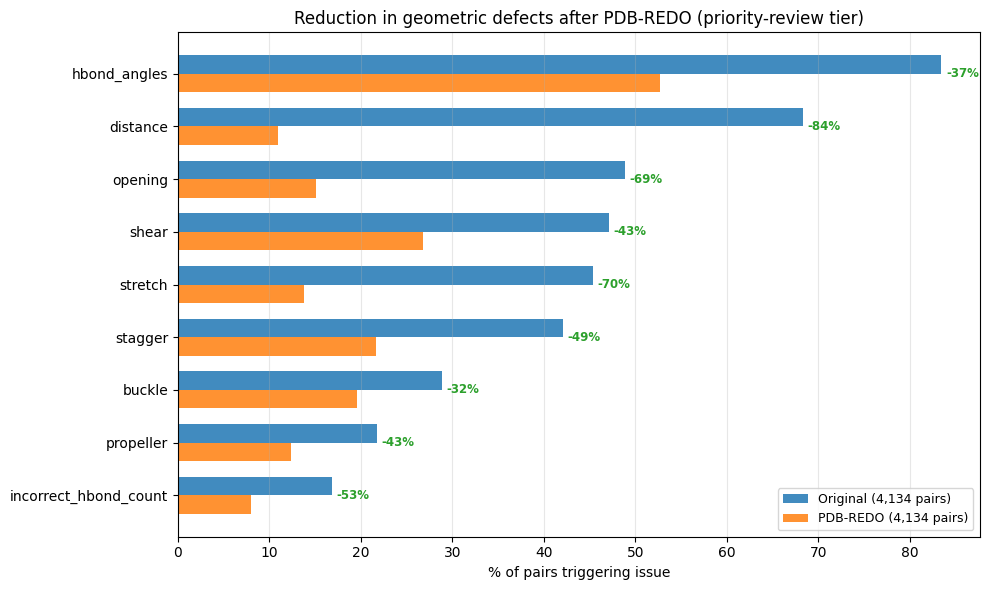

In [4]:
sub = df[df['orig_score'] < LOW_THRESH]
orig_rates, n_orig = issue_rates(sub, 'orig_issues')
redo_rates, n_redo = issue_rates(sub, 'redo_issues')
all_issues = sorted(set(orig_rates) | set(redo_rates), key=lambda k: orig_rates.get(k, 0))
y = np.arange(len(all_issues)); w = 0.35
op = [100 * orig_rates.get(k, 0) for k in all_issues]
rp = [100 * redo_rates.get(k, 0) for k in all_issues]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + w/2, op, w, label=f'Original ({n_orig:,} pairs)', color='tab:blue', alpha=0.85)
ax.barh(y - w/2, rp, w, label=f'PDB-REDO ({n_redo:,} pairs)', color='tab:orange', alpha=0.85)
for i, (o, r) in enumerate(zip(op, rp)):
    if o <= 0: continue
    ax.text(max(o, r) + 0.5, i, f'{100*(r-o)/o:+.0f}%', ha='left', va='center',
            fontsize=8.5, fontweight='bold', color='tab:green' if r < o else 'tab:red')
ax.set_yticks(y); ax.set_yticklabels(all_issues, fontsize=10)
ax.set_xlabel('% of pairs triggering issue')
ax.set_title('Reduction in geometric defects after PDB-REDO (priority-review tier)')
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
fig.tight_layout(); print('saved', savefig(fig, 'figure4_C_issue_reduction.png')); plt.show()